# Capstone Project – ABG Motors Market Entry Analysis
## Classification Model on the Japanese Dataset (Predicting PURCHASE)

**Goal:** Using attributes from the Japanese dataset (age, gender, income, age of current car), predict whether a customer **will buy (1) or not (0)**, then apply the model to the Indian dataset.

**Steps:**
1. Libraries & data load
2. Data understanding & cleaning
3. EDA (graphs)
4. Feature preparation (encoding, split, scaling)
5. Train and compare multiple models
6. Hyperparameter tuning
7. Final model evaluation
8. Feature importance
9. Prediction demo for a new customer
10. Applying the model to India
11. Conclusion & justification of decisions

## Step 1: Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)

sns.set_style('whitegrid')
RANDOM_STATE = 42

In [3]:
# The Excel file must be in the same folder as this notebook
jp = pd.read_excel('JPN Data.xlsx')
print(jp.shape)
jp.head()

(40000, 6)


,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,00001Q15YJ,50,M,445344.000000,439,0
1,00003I71CQ,35,M,107634.000000,283,0
2,00003N47FS,59,F,502786.666667,390,1
3,00005H41DE,43,M,585664.000000,475,0
4,00007E17UM,39,F,705722.666667,497,1


## Step 2: Data understanding & cleaning
Columns:
- `ID` – customer id (identifier only)
- `CURR_AGE` – customer's age
- `GENDER` – M / F
- `ANN_INCOME` – annual income
- `AGE_CAR` – age of the customer's current car
- `PURCHASE` – **Target** (1 = bought, 0 = did not buy)

In [4]:
jp.info()
print()
print('Missing values:\n', jp.isnull().sum())
print('\nDuplicate rows:', jp.duplicated().sum())
print('Duplicate IDs :', jp['ID'].duplicated().sum())
jp.describe()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          40000 non-null  str    
 1   CURR_AGE    40000 non-null  int64  
 2   GENDER      40000 non-null  str    
 3   ANN_INCOME  40000 non-null  float64
 4   AGE_CAR     40000 non-null  int64  
 5   PURCHASE    40000 non-null  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 2.3 MB

Missing values:
 ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
AGE_CAR       0
PURCHASE      0
dtype: int64

Duplicate rows: 0
Duplicate IDs : 0


,CURR_AGE,ANN_INCOME,AGE_CAR,PURCHASE
count,40000.00000,40000.000000,40000.000000,40000.000000
mean,44.99745,359398.878050,359.080250,0.575775
std,11.82008,175109.262950,203.063724,0.494231
min,25.00000,70089.000000,1.000000,0.000000
25%,35.00000,219766.000000,235.000000,0.000000
50%,45.00000,337656.833333,331.000000,1.000000
75%,55.00000,464261.000000,444.000000,1.000000
max,65.00000,799970.666667,1020.000000,1.000000


**Observation:** There are no missing values or duplicates, so no imputation or removal is needed.

**Decision:** `ID` is just a unique label and contains no pattern. If we include it, the model would learn noise (overfitting), so we **drop** it.

## Step 3: EDA (Exploratory Data Analysis)

PURCHASE
1    23031
0    16969
Name: count, dtype: int64
PURCHASE
1    0.576
0    0.424
Name: proportion, dtype: float64


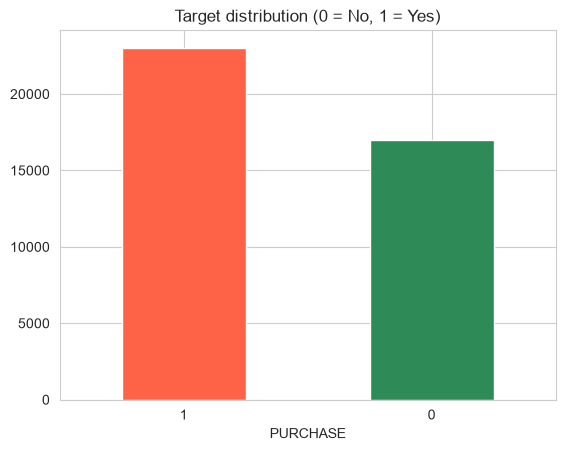

In [5]:
# Target balance
print(jp['PURCHASE'].value_counts())
print(jp['PURCHASE'].value_counts(normalize=True).round(3))
jp['PURCHASE'].value_counts().plot(kind='bar', color=['tomato','seagreen'])
plt.title('Target distribution (0 = No, 1 = Yes)'); plt.xticks(rotation=0); plt.show()

**Observation:** About 58% of customers purchased and 42% did not. The data is **roughly balanced**, so SMOTE/oversampling is not needed. We only use `stratify` in the train-test split so that the ratio stays the same.

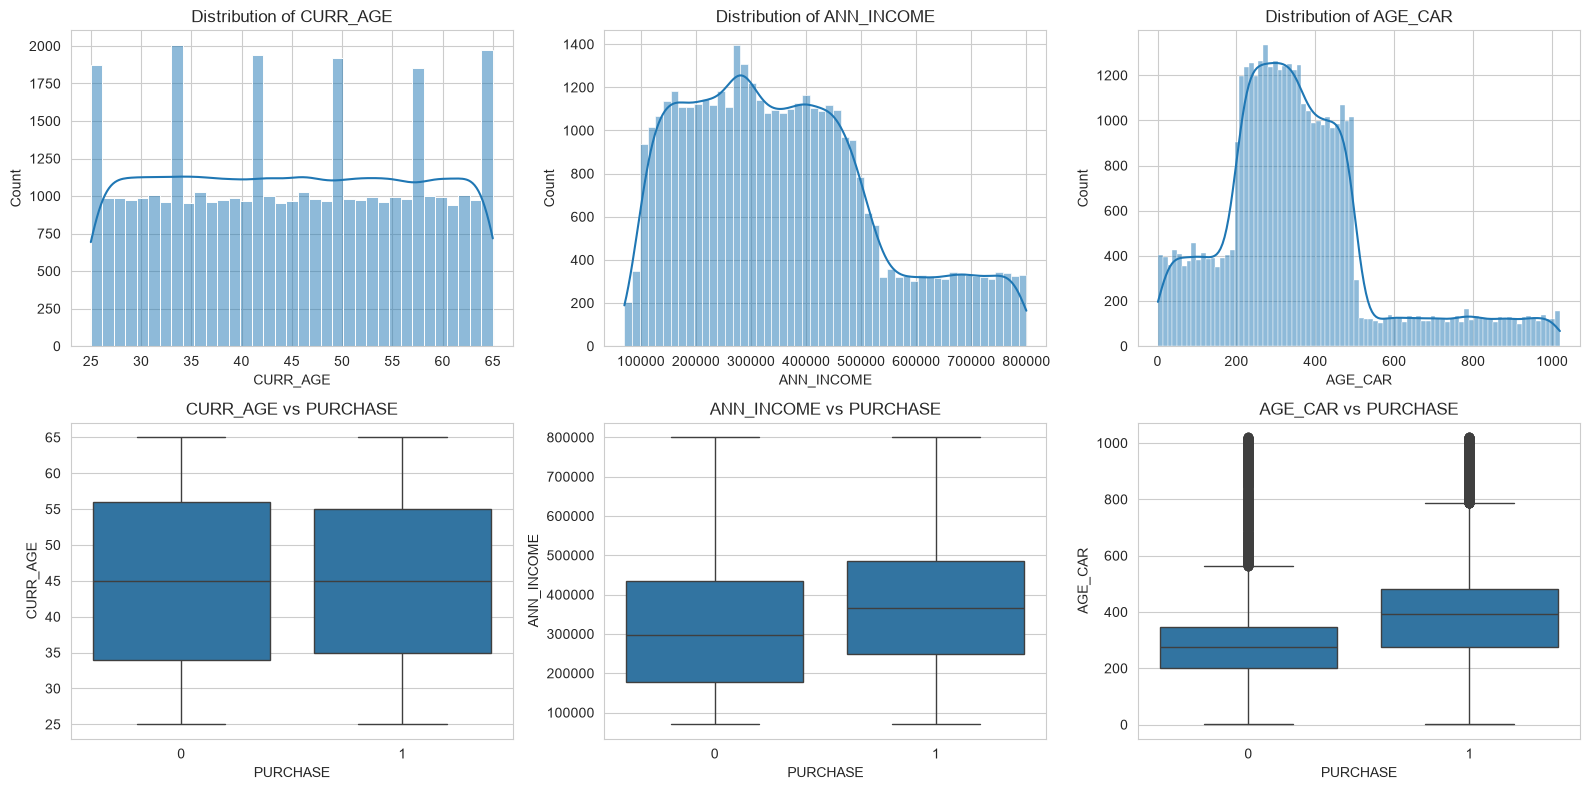

In [6]:
num_cols = ['CURR_AGE','ANN_INCOME','AGE_CAR']
fig, ax = plt.subplots(2, 3, figsize=(16,8))
for i,c in enumerate(num_cols):
    sns.histplot(jp[c], kde=True, ax=ax[0,i]); ax[0,i].set_title(f'Distribution of {c}')
    sns.boxplot(x='PURCHASE', y=c, data=jp, ax=ax[1,i]); ax[1,i].set_title(f'{c} vs PURCHASE')
plt.tight_layout(); plt.show()

In [7]:
# Outlier check (IQR method)
for c in num_cols:
    q1,q3 = jp[c].quantile([.25,.75]); iqr=q3-q1
    n = ((jp[c]<q1-1.5*iqr)|(jp[c]>q3+1.5*iqr)).sum()
    print(f'{c}: {n} outliers ({n/len(jp):.1%})')

CURR_AGE: 0 outliers (0.0%)
ANN_INCOME: 0 outliers (0.0%)
AGE_CAR: 2714 outliers (6.8%)


**Observation:** Only `AGE_CAR` has some outliers (~7%). The distribution is right-skewed because of a few very old cars.

**Decision:** We are **not removing** the outliers, because:
- These are real customers, not errors (people with older cars are actually more likely to buy).
- Removing 7% of the data would mean losing useful information.
- Tree-based models are not affected by outliers, and for Logistic Regression we use scaling.

GENDER
F    0.555
M    0.592
Name: PURCHASE, dtype: float64


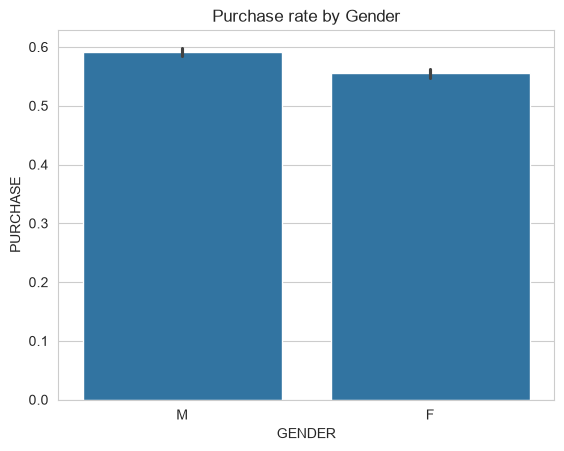

In [8]:
# Categorical column vs target
print(jp.groupby('GENDER')['PURCHASE'].mean().round(3))
sns.barplot(x='GENDER', y='PURCHASE', data=jp); plt.title('Purchase rate by Gender'); plt.show()

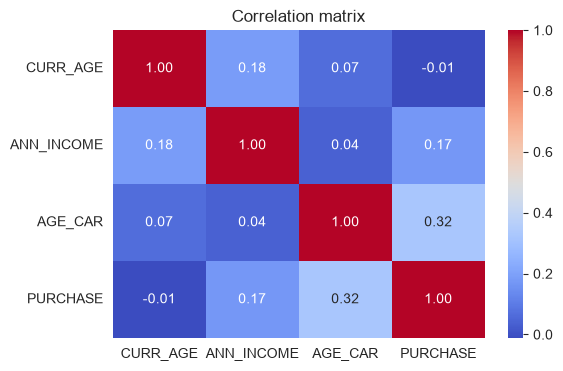

In [9]:
# Correlation
plt.figure(figsize=(6,4))
sns.heatmap(jp[num_cols+['PURCHASE']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix'); plt.show()

**EDA insights:**
- `AGE_CAR` has the strongest relationship with the target (~0.32): the older a customer's car, the more likely they are to buy.
- `ANN_INCOME` has a positive relationship (~0.17): customers with higher income are more likely to buy.
- `CURR_AGE` has almost no relationship with the target (~ -0.01).
- Gender has a slight effect (the purchase rate is a little higher for males).
- The features are not highly correlated with each other, so there is **no multicollinearity problem**.

## Step 4: Feature preparation

In [10]:
df = jp.drop(columns=['ID']).copy()

# Convert GENDER to numbers (M=1, F=0) - models cannot work with text
df['GENDER'] = df['GENDER'].map({'M':1, 'F':0})

X = df.drop(columns=['PURCHASE'])
y = df['PURCHASE']

# 80% train / 20% test; stratify keeps the target ratio the same
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(X_train.shape, X_test.shape)
print('Train purchase rate:', y_train.mean().round(3), '| Test purchase rate:', y_test.mean().round(3))

(32000, 4) (8000, 4)
Train purchase rate: 0.576 | Test purchase rate: 0.576


**Justification:**
- **Label encoding for GENDER:** There are only 2 categories, so 0/1 encoding is enough (one-hot encoding would give the same result).
- **Train-test split (80/20):** This lets us test the model on unseen data, so that overfitting can be detected.
- **Scaling:** Income is in the hundreds of thousands while age is between 25 and 65. Logistic Regression is scale-sensitive, so we apply scaling inside a Pipeline (so that no test data leaks into the training process).

## Step 5: Train and compare multiple models

In [11]:
models = {
    'Logistic Regression': Pipeline([('scale', StandardScaler()),
                                     ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=RANDOM_STATE),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, m in models.items():
    cv_auc = cross_val_score(m, X_train, y_train, cv=skf, scoring='roc_auc').mean()
    m.fit(X_train, y_train)
    pred = m.predict(X_test); prob = m.predict_proba(X_test)[:,1]
    rows.append({'Model':name, 'CV ROC-AUC':cv_auc,
                 'Test Accuracy':accuracy_score(y_test,pred),
                 'Precision':precision_score(y_test,pred),
                 'Recall':recall_score(y_test,pred),
                 'F1':f1_score(y_test,pred),
                 'Test ROC-AUC':roc_auc_score(y_test,prob)})
results = pd.DataFrame(rows).set_index('Model').round(4)
results.sort_values('Test ROC-AUC', ascending=False)

,CV ROC-AUC,Test Accuracy,Precision,Recall,F1,Test ROC-AUC
Model,,,,,,
Random Forest,0.7771,0.7028,0.7487,0.7282,0.7383,0.7841
Decision Tree,0.7722,0.7039,0.7377,0.7536,0.7456,0.7828
Gradient Boosting,0.7733,0.7039,0.7659,0.6995,0.7312,0.7824
Logistic Regression,0.7259,0.6708,0.6890,0.7803,0.7318,0.7221


**Model selection logic:**
- Logistic Regression = a simple, interpretable baseline.
- Decision Tree = easy to explain and captures non-linear relationships.
- Random Forest / Gradient Boosting = ensemble methods that usually give the best accuracy.
- **5-fold cross validation** checks that the result is not just due to one lucky split.
- **Metrics:** Along with accuracy, we also looked at Precision, Recall, F1 and ROC-AUC, because accuracy alone does not tell the whole story.

## Step 6: Hyperparameter tuning (best model)

In [12]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4],
}
grid = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE),
                    param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV ROC-AUC:', round(grid.best_score_,4))
best = grid.best_estimator_

Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Best CV ROC-AUC: 0.775


## Step 7: Final model evaluation

Accuracy : 0.7067
ROC-AUC  : 0.7838

              precision    recall  f1-score   support

 No Purchase       0.64      0.70      0.67      3394
    Purchase       0.76      0.72      0.74      4606

    accuracy                           0.71      8000
   macro avg       0.70      0.71      0.70      8000
weighted avg       0.71      0.71      0.71      8000



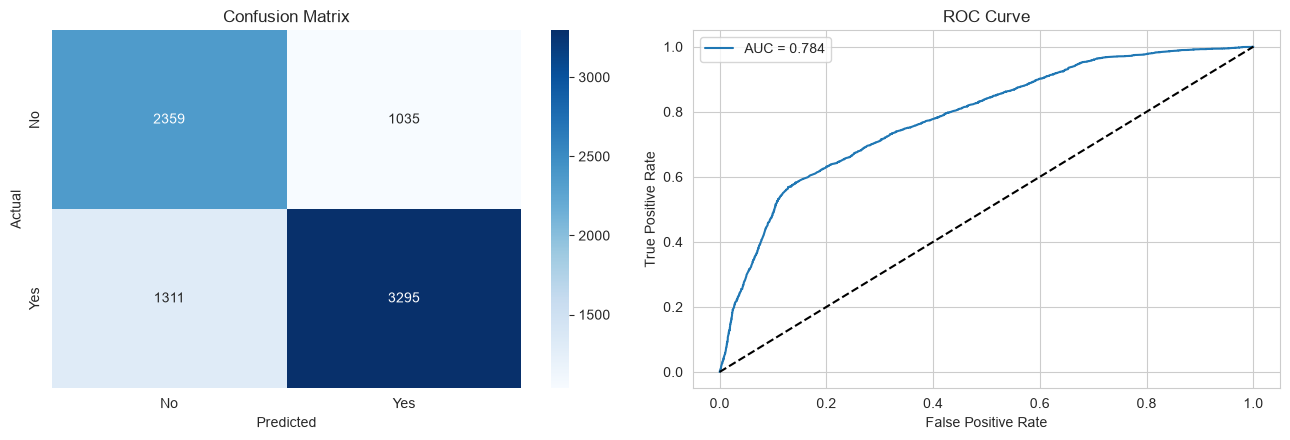

In [13]:
pred = best.predict(X_test)
prob = best.predict_proba(X_test)[:,1]

print('Accuracy :', round(accuracy_score(y_test,pred),4))
print('ROC-AUC  :', round(roc_auc_score(y_test,prob),4))
print()
print(classification_report(y_test, pred, target_names=['No Purchase','Purchase']))

fig, ax = plt.subplots(1,2, figsize=(13,4.5))
sns.heatmap(confusion_matrix(y_test,pred), annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
ax[0].set_title('Confusion Matrix'); ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')
fpr,tpr,_ = roc_curve(y_test, prob)
ax[1].plot(fpr,tpr,label=f'AUC = {roc_auc_score(y_test,prob):.3f}'); ax[1].plot([0,1],[0,1],'k--')
ax[1].set_title('ROC Curve'); ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate'); ax[1].legend()
plt.tight_layout(); plt.show()

In [14]:
# Overfitting check: train vs test accuracy
print('Train accuracy:', round(accuracy_score(y_train, best.predict(X_train)),4))
print('Test accuracy :', round(accuracy_score(y_test, pred),4))

Train accuracy: 0.7068
Test accuracy : 0.7067


## Step 8: Feature importance

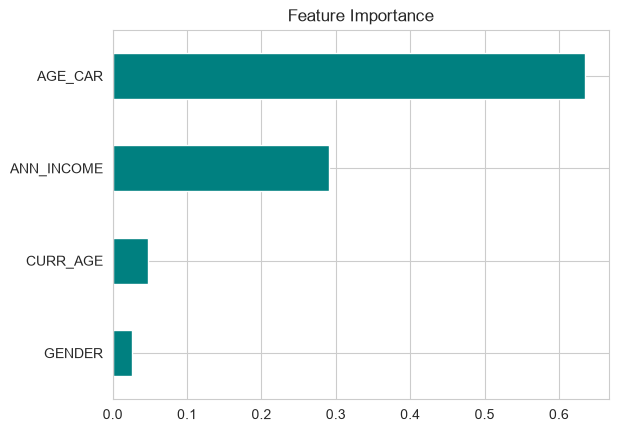

AGE_CAR       0.635126
ANN_INCOME    0.291358
CURR_AGE      0.047364
GENDER        0.026152
dtype: float64

In [15]:
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', color='teal'); plt.title('Feature Importance'); plt.show()
imp.sort_values(ascending=False)

## Step 9: Prediction demo for a new customer

In [16]:
new_customer = pd.DataFrame({'CURR_AGE':[40], 'GENDER':[1], 'ANN_INCOME':[500000], 'AGE_CAR':[450]})
p = best.predict_proba(new_customer)[0,1]
print(f'Purchase probability: {p:.1%} ->', 'Likely BUYER' if p>=0.5 else 'Unlikely buyer')

Purchase probability: 87.2% -> Likely BUYER


## Step 10: Applying the model to India
The company needs a forecast of whether **at least 12,000 customers** in the Indian sample data will buy a car.

**Problems with the Indian data and how we solve them:**
1. The Indian data has no `AGE_CAR`, only `DT_MAINT` (last maintenance date). In Japan, `AGE_CAR` ranges from 1 to 1020. In India, `DT_MAINT` runs from 2016-09-14 to 2019-06-30, and with a reference date of **2019-07-01** the derived `AGE_CAR` range is exactly 1 to 1020 as well. So `AGE_CAR` = (2019-07-01 minus DT_MAINT) in **days**.
2. Indian income is in **Rupees** and Japanese income is in **Yen**, and the scales are very different (India's average is ~1.15 million, Japan's ~0.36 million). Feeding it directly into the model would put income outside Japan's range. So in the base case we match Indian income to Japanese income by **percentile (rank)** (India's 80th percentile customer = Japan's 80th percentile customer). This follows the company's belief that the Indian market is similar to Japan.
3. To show the result is robust, we also run a sensitivity check (different income assumptions).

In [17]:
india = pd.read_excel('IN_Data.xlsx', sheet_name='IN_Mobiles')
print(india.shape)

# Create AGE_CAR (in days)
ref_date = pd.Timestamp('2019-07-01')
india['AGE_CAR'] = (ref_date - india['DT_MAINT']).dt.days
print('India AGE_CAR range:', india['AGE_CAR'].min(), '-', india['AGE_CAR'].max(), '| Japan:', jp['AGE_CAR'].min(), '-', jp['AGE_CAR'].max())

# Match income to Japanese income by percentile
pct = india['ANN_INCOME'].rank(pct=True).clip(0, 1)
india['INCOME_JP_SCALE'] = jp['ANN_INCOME'].quantile(pct).values

india_X = pd.DataFrame({'CURR_AGE': india['CURR_AGE'],
                        'GENDER': india['GENDER'].map({'M':1,'F':0}),
                        'ANN_INCOME': india['INCOME_JP_SCALE'],
                        'AGE_CAR': india['AGE_CAR']})[X.columns]

india['PURCHASE_PROBABILITY'] = best.predict_proba(india_X)[:,1].round(3)
india['PREDICTED_PURCHASE'] = best.predict(india_X)

print('Predicted buyers (hard 0/1)     :', india['PREDICTED_PURCHASE'].sum())
print('Expected buyers (sum of probab.):', round(india['PURCHASE_PROBABILITY'].sum()))
print('Target                          : 12000')

(70000, 5)
India AGE_CAR range: 1 - 1020 | Japan: 1 - 1020
Predicted buyers (hard 0/1)     : 39066
Expected buyers (sum of probab.): 40471
Target                          : 12000


In [18]:
# Sensitivity check: result under different income assumptions
def count_buyers(income_values):
    Z = india_X.copy(); Z['ANN_INCOME'] = income_values
    p = best.predict_proba(Z)[:,1]
    return int((p>=0.5).sum()), round(p.sum())

scenarios = {
    'Base: income percentile-matched to Japan': india['INCOME_JP_SCALE'].values,
    'Raw India income (no conversion)':        india['ANN_INCOME'].values,
    'INR to JPY at 1.7':                       (india['ANN_INCOME']*1.7).values,
    'Worst case: everyone at Japan min income': np.full(len(india), jp['ANN_INCOME'].min()),
}
sens = pd.DataFrame([(k,)+count_buyers(v) for k,v in scenarios.items()],
                    columns=['Scenario','Predicted buyers (0/1)','Expected buyers (sum prob.)'])
sens['Target 12,000 met?'] = np.where(sens['Expected buyers (sum prob.)']>=12000,'Yes','No')
sens

,Scenario,Predicted buyers (0/1),Expected buyers (sum prob.),"Target 12,000 met?"
0,Base: income percentile-matched to Japan,39066,40471,Yes
1,Raw India income (no conversion),61868,48598,Yes
2,INR to JPY at 1.7,65161,48941,Yes
3,Worst case: everyone at Japan min income,4202,16189,Yes


In [19]:
# Save India predictions for dashboard / Tableau
india['AGE_GROUP'] = pd.cut(india['CURR_AGE'], [24,35,45,55,65], labels=['25-35','36-45','46-55','56-65']).astype(str)
india['AGE_CAR_GROUP'] = pd.cut(india['AGE_CAR'], [0,200,400,600,2000], labels=['0-200','201-400','401-600','600+']).astype(str)
india.drop(columns=['DT_MAINT']).to_csv('IN_for_Tableau.csv', index=False)
india.groupby('AGE_CAR_GROUP')['PURCHASE_PROBABILITY'].mean().round(3)

AGE_CAR_GROUP
0-200      0.361
201-400    0.499
401-600    0.778
600+       0.821
Name: PURCHASE_PROBABILITY, dtype: float64

## Step 11: Conclusion

**Result:** The final tuned Gradient Boosting model achieves about **71% accuracy** and a **ROC-AUC of ~0.78** on the test data. Train and test accuracy are almost the same (~70.7%), which means there is **no overfitting**.

**Model comparison:** The tree-based models (Random Forest, Decision Tree, Gradient Boosting) perform almost the same (AUC ~0.78) and are better than Logistic Regression (~0.72), which shows that the data has **non-linear relationships**. We chose Gradient Boosting because it is stable and generalizes well after tuning.

**Limitation:** There are only 4 features, so it is hard to go much beyond ~71% accuracy. With more features (such as car model or family size), accuracy could improve.

**Key drivers:** `AGE_CAR` (most important) and `ANN_INCOME`. `CURR_AGE` and `GENDER` have a smaller effect.

**India forecast:** Applying the Japanese model to the 70,000 Indian customers, about **40,000 customers** (base case) are expected to buy, which is **far above the 12,000 target**. Even under the worst-case income assumption, expected buyers are about 16,000, so the target is still met. **Recommendation: ABG Motors should enter the Indian market.**

**Caveat:** This forecast assumes Indian customers behave like Japanese customers (which is the company's own belief). In real sales, price, competition and brand also matter.

**Business meaning for ABG Motors:** The target customers are those whose current car is old and who have a higher income. When entering India, marketing should focus on these segments.

**Summary of all decisions:**
| Decision | Reason |
|---|---|
| Dropped ID | It is only an identifier and has no predictive information |
| Kept outliers | Real values, tree models are robust, avoids information loss |
| Did not use SMOTE | Classes are balanced (58/42) |
| Stratified split | Keeps the same target ratio in train and test sets |
| Scaling (Logistic Regression only) | It is a scale-sensitive model; the Pipeline prevents data leakage |
| 4 models + CV | Fair comparison, and protects against a lucky split |
| Also used ROC-AUC + F1 | Accuracy alone is not enough |
| GridSearchCV | To find the best hyperparameters |
| AGE_CAR derived from DT_MAINT (days) | India has no AGE_CAR; the derived range matches Japan exactly |
| Income percentile-matched for India | Different currency and scale; avoids going outside Japan's range |
| Sensitivity analysis | Shows the conclusion holds under different assumptions |